# IMDb Movie Data Analysis
### Exploratory Data Analysis of 1,000 Popular Movies (2006–2016)

This notebook explores a dataset of 1,000 popular IMDb movies, looking at rating distributions, genre trends, runtime/revenue relationships, and top directors.

**Dataset fields:** Title, Genre, Description, Director, Actors, Year, Runtime, Rating, Votes, Revenue, Metascore


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
%matplotlib inline

## 1. Load & Clean the Data

In [2]:
df = pd.read_csv('data/IMDB-Movie-Data.csv')
df.columns = [c.strip() for c in df.columns]
df.rename(columns={'Runtime (Minutes)': 'Runtime', 'Revenue (Millions)': 'Revenue'}, inplace=True)

# Treat 0s in Revenue/Metascore as missing (a movie can't truly gross $0 or score 0)
df['Revenue'] = df['Revenue'].replace(0, np.nan)
df['Metascore'] = df['Metascore'].replace(0, np.nan)
df['Primary_Genre'] = df['Genre'].apply(lambda x: x.split(',')[0])

print(df.shape)
df.head()

(1000, 13)


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime,Rating,Votes,Revenue,Metascore,Primary_Genre
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76,Action
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65,Adventure
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62,Horror
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59,Animation
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40,Action


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           1000 non-null   int64  
 1   Title          1000 non-null   str    
 2   Genre          1000 non-null   str    
 3   Description    1000 non-null   str    
 4   Director       1000 non-null   str    
 5   Actors         1000 non-null   str    
 6   Year           1000 non-null   int64  
 7   Runtime        1000 non-null   int64  
 8   Rating         1000 non-null   float64
 9   Votes          1000 non-null   int64  
 10  Revenue        871 non-null    float64
 11  Metascore      1000 non-null   int64  
 12  Primary_Genre  1000 non-null   str    
dtypes: float64(2), int64(5), str(6)
memory usage: 101.7 KB


In [4]:
df.isna().sum()

Rank               0
Title              0
Genre              0
Description        0
Director           0
Actors             0
Year               0
Runtime            0
Rating             0
Votes              0
Revenue          129
Metascore          0
Primary_Genre      0
dtype: int64

## 2. Key Summary Statistics

In [5]:
summary = {
    'n_movies': len(df),
    'year_range': (int(df.Year.min()), int(df.Year.max())),
    'avg_rating': round(df.Rating.mean(), 2),
    'median_rating': round(df.Rating.median(), 2),
    'avg_runtime': round(df.Runtime.mean(), 1),
    'avg_revenue_M': round(df.Revenue.mean(skipna=True), 1),
    'missing_revenue': int(df.Revenue.isna().sum()),
    'n_unique_directors': df.Director.nunique(),
    'top_genre': df.Primary_Genre.value_counts().idxmax(),
}
summary

{'n_movies': 1000,
 'year_range': (2006, 2016),
 'avg_rating': np.float64(6.72),
 'median_rating': np.float64(6.8),
 'avg_runtime': np.float64(113.2),
 'avg_revenue_M': np.float64(83.1),
 'missing_revenue': 129,
 'n_unique_directors': 644,
 'top_genre': 'Action'}

## 3. Ratings Analysis

### 3.1 Distribution of IMDb Ratings
Ratings are approximately bell-shaped and centred in the mid-to-high 6s — this dataset is pre-filtered to "popular" movies, so very poorly rated films are underrepresented.

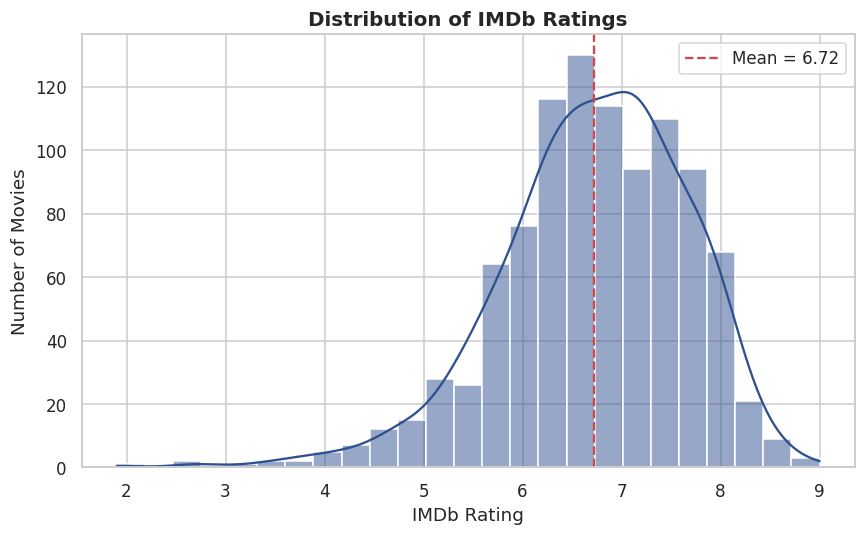

In [6]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['Rating'], bins=25, kde=True, color='#2E5090', ax=ax)
ax.axvline(df['Rating'].mean(), color='#D64545', linestyle='--', linewidth=1.5,
           label=f"Mean = {df['Rating'].mean():.2f}")
ax.set_title('Distribution of IMDb Ratings', fontsize=13, fontweight='bold')
ax.set_xlabel('IMDb Rating'); ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Ratings Over Time
Average ratings are fairly stable year to year, with no strong upward or downward trend.

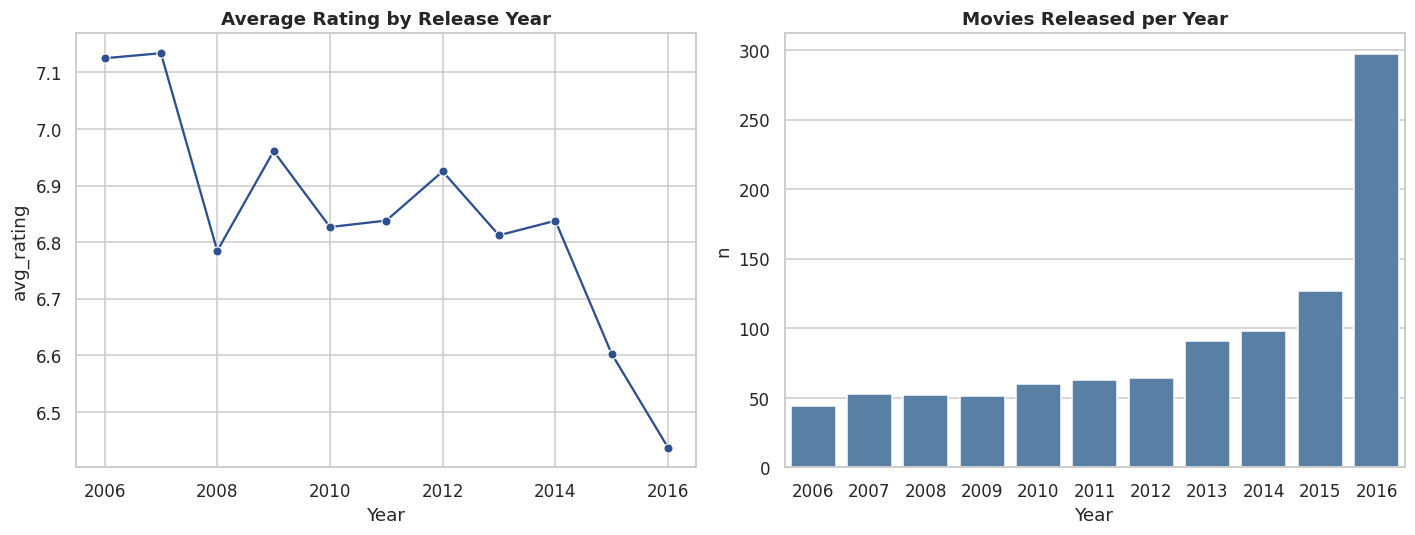

In [7]:
yearly = df.groupby('Year').agg(avg_rating=('Rating', 'mean'), n=('Rating', 'size')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.lineplot(data=yearly, x='Year', y='avg_rating', marker='o', color='#2E5090', ax=axes[0])
axes[0].set_title('Average Rating by Release Year', fontweight='bold')

sns.barplot(x=yearly['Year'], y=yearly['n'], color='#4C7FB0', ax=axes[1])
axes[1].set_title('Movies Released per Year', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Top-Rated Movies

In [8]:
df.sort_values('Rating', ascending=False)[['Title','Year','Rating','Votes','Director']].head(10)

,Title,Year,Rating,Votes,Director
54,The Dark Knight,2008,9.0,1791916,Christopher Nolan
80,Inception,2010,8.8,1583625,Christopher Nolan
117,Dangal,2016,8.8,48969,Nitesh Tiwari
96,Kimi no na wa,2016,8.6,34110,Makoto Shinkai
36,Interstellar,2014,8.6,1047747,Christopher Nolan
249,The Intouchables,2011,8.6,557965,Olivier Nakache
99,The Departed,2006,8.5,937414,Martin Scorsese
124,The Dark Knight Rises,2012,8.5,1222645,Christopher Nolan
133,Whiplash,2014,8.5,477276,Damien Chazelle
64,The Prestige,2006,8.5,913152,Christopher Nolan


## 4. Genre Analysis

### 4.1 Most Common Genres

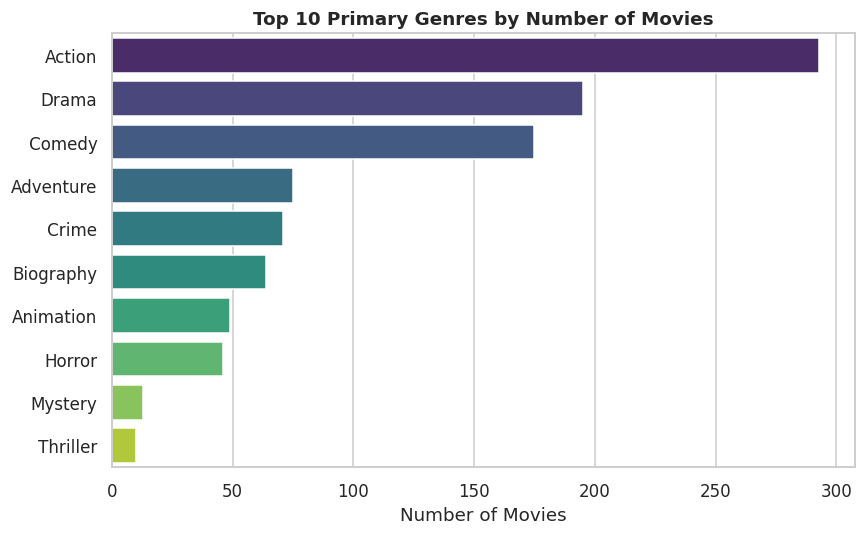

In [9]:
genre_counts = df['Primary_Genre'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index,
            palette='viridis', legend=False, ax=ax)
ax.set_title('Top 10 Primary Genres by Number of Movies', fontweight='bold')
ax.set_xlabel('Number of Movies'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4.2 Average Rating by Genre
Biography, Animation, and Crime tend to rate higher on average than the highest-volume genres (Action, Comedy).

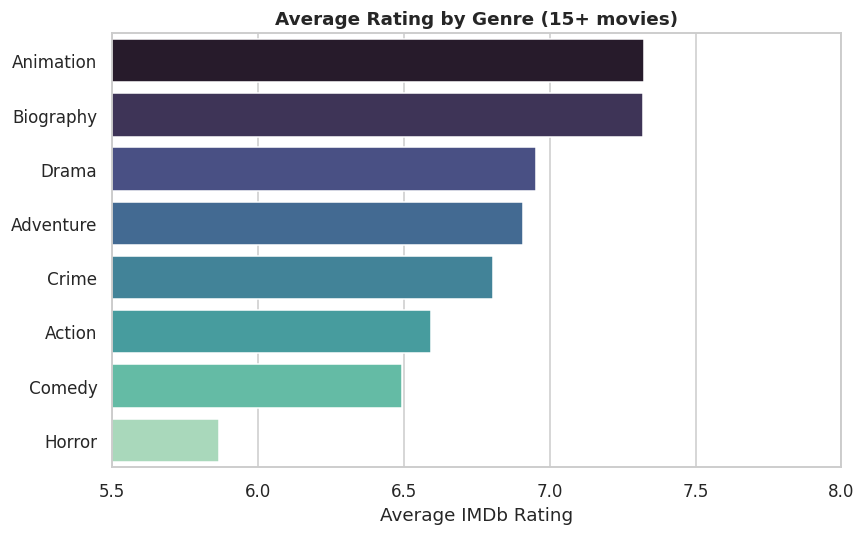

In [10]:
genre_stats = (df.groupby('Primary_Genre')
                 .agg(count=('Rating', 'size'), avg_rating=('Rating', 'mean'))
                 .query('count >= 15')
                 .sort_values('avg_rating', ascending=False))

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=genre_stats['avg_rating'], y=genre_stats.index, hue=genre_stats.index,
            palette='mako', legend=False, ax=ax)
ax.set_title('Average Rating by Genre (15+ movies)', fontweight='bold')
ax.set_xlabel('Average IMDb Rating'); ax.set_ylabel('')
ax.set_xlim(5.5, 8)
plt.tight_layout()
plt.show()

## 5. Runtime, Revenue & Rating Relationships

### 5.1 Runtime vs. Rating
Weak positive relationship — longer movies trend slightly higher-rated, but variance is wide.

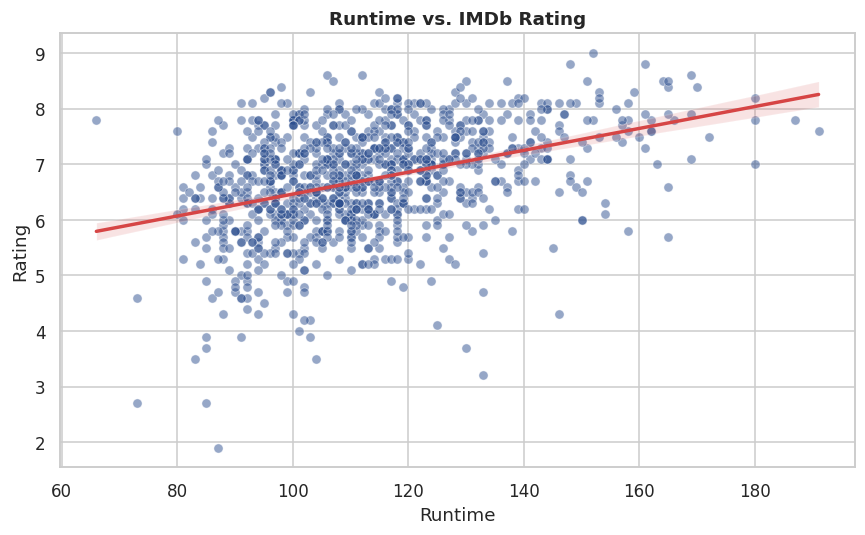

,Runtime,Rating
Runtime,1.000000,0.392214
Rating,0.392214,1.000000


In [11]:
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df, x='Runtime', y='Rating', alpha=0.5, color='#2E5090', ax=ax)
sns.regplot(data=df, x='Runtime', y='Rating', scatter=False, color='#D64545', ax=ax)
ax.set_title('Runtime vs. IMDb Rating', fontweight='bold')
plt.tight_layout()
plt.show()

df[['Runtime','Rating']].corr()

### 5.2 Revenue vs. Rating
Rating is only a weak predictor of box office revenue.

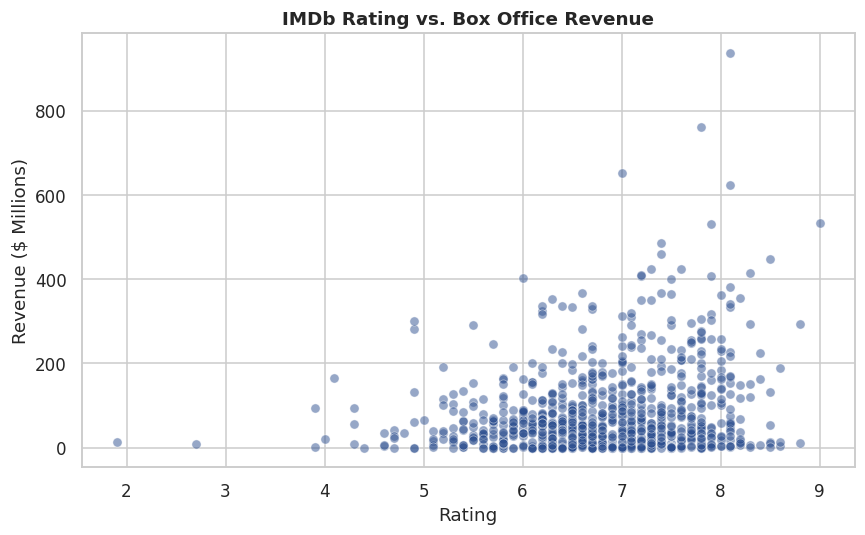

,Rating,Revenue
Rating,1.000000,0.216461
Revenue,0.216461,1.000000


In [12]:
sub = df.dropna(subset=['Revenue'])

fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=sub, x='Rating', y='Revenue', alpha=0.5, color='#2E5090', ax=ax)
ax.set_title('IMDb Rating vs. Box Office Revenue', fontweight='bold')
ax.set_ylabel('Revenue ($ Millions)')
plt.tight_layout()
plt.show()

sub[['Rating','Revenue']].corr()

### 5.3 Correlation Matrix

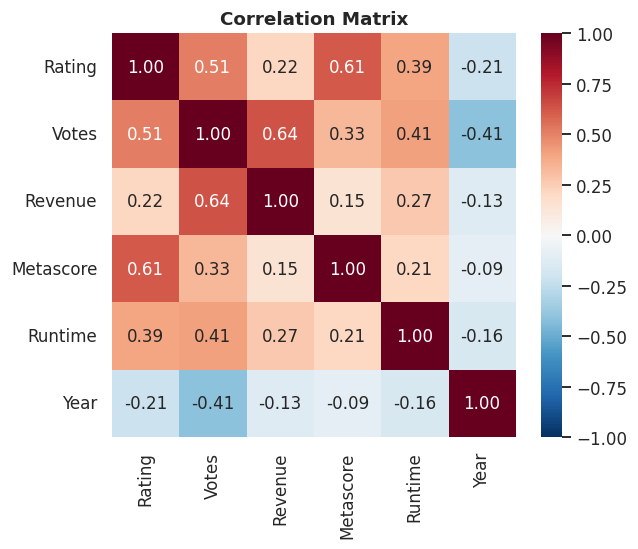

In [13]:
num_cols = ['Rating','Votes','Revenue','Metascore','Runtime','Year']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=ax)
ax.set_title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Directors & Commercial Performance

### 6.1 Top Directors by Average Rating (3+ movies)

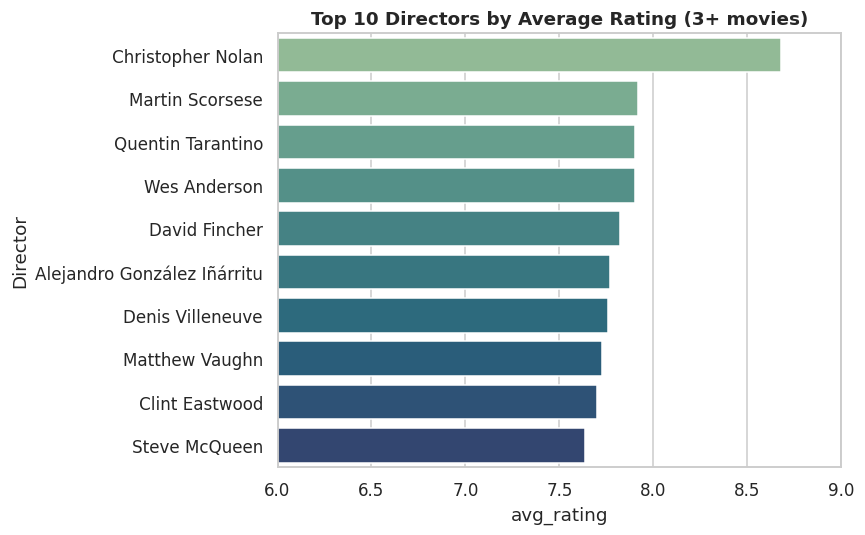

In [14]:
dir_stats = (df.groupby('Director')
               .agg(count=('Rating', 'size'), avg_rating=('Rating', 'mean'))
               .query('count >= 3')
               .sort_values('avg_rating', ascending=False)
               .head(10))

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=dir_stats['avg_rating'], y=dir_stats.index, hue=dir_stats.index,
            palette='crest', legend=False, ax=ax)
ax.set_title('Top 10 Directors by Average Rating (3+ movies)', fontweight='bold')
ax.set_xlim(6, 9)
plt.tight_layout()
plt.show()

### 6.2 Highest-Grossing Movies

In [15]:
df.sort_values('Revenue', ascending=False)[['Title','Year','Revenue','Rating']].head(10)

,Title,Year,Revenue,Rating
50,Star Wars: Episode VII - The Force Awakens,2015,936.63,8.1
87,Avatar,2009,760.51,7.8
85,Jurassic World,2015,652.18,7.0
76,The Avengers,2012,623.28,8.1
54,The Dark Knight,2008,533.32,9.0
12,Rogue One,2016,532.17,7.9
119,Finding Dory,2016,486.29,7.4
94,Avengers: Age of Ultron,2015,458.99,7.4
124,The Dark Knight Rises,2012,448.13,8.5
578,The Hunger Games: Catching Fire,2013,424.65,7.6


## 7. Key Findings

- Ratings cluster around **6.7–6.8** on average — expected, since this is a "popular movies" sample, not a random one.
- **Action, Comedy, and Drama** dominate by volume, but **Biography, Animation, and Crime** tend to rate higher on average.
- **Runtime** has only a weak positive correlation with rating.
- **Revenue and rating are weakly correlated** — critical/audience approval doesn't reliably predict box office success.
- **Votes correlate more strongly with rating than revenue does**, suggesting engagement matters as much as earnings.
- A small set of directors (Christopher Nolan, Damien Chazelle, etc.) account for a disproportionate share of top-rated titles.

## 8. Data Source

Dataset: 1,000 popular IMDb movies (2006–2016) — Title, Genre, Description, Director, Actors, Year, Runtime, Rating, Votes, Revenue, Metascore.
Zero values in `Revenue`/`Metascore` were treated as missing, not literal zero.
